# DS 3000 Mini-Project
Dylan McCormick and Ali Salha

## Step 1: Import Libraries

In [ ]:
%pip install numpy
%pip install pandas

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd
import kagglehub

## Step 2: Import and Clean Data

### Import Data

In [ ]:
# Download latest version
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")
path += '/dataset.csv'

# preview df
df = pd.read_csv(path)
df.columns.tolist()

['Unnamed: 0',
 'track_id',
 'artists',
 'album_name',
 'track_name',
 'popularity',
 'duration_ms',
 'explicit',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature',
 'track_genre']

In [ ]:
# preview data
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### Clean + Normalize Data

In [ ]:
# drop junk columns/rows
df = df.drop(columns=["Unnamed: 0"])
df = df.dropna()

# convert bool to int
df["explicit"] = df["explicit"].astype(int)

# define feature columns
feature_cols = [
    "danceability",
    "energy",
    "loudness",
    "tempo",
    "valence",
    "acousticness",
    "instrumentalness",
    "speechiness",
    "liveness",
    "duration_ms",
    "mode",
    "time_signature",
    "explicit"
]

X = df[feature_cols].to_numpy()
X

array([[  0.676,   0.461,  -6.746, ...,   0.   ,   4.   ,   0.   ],
       [  0.42 ,   0.166, -17.235, ...,   1.   ,   4.   ,   0.   ],
       [  0.438,   0.359,  -9.734, ...,   1.   ,   4.   ,   0.   ],
       ...,
       [  0.629,   0.329, -10.895, ...,   0.   ,   4.   ,   0.   ],
       [  0.587,   0.506, -10.889, ...,   1.   ,   4.   ,   0.   ],
       [  0.526,   0.487, -10.204, ...,   0.   ,   4.   ,   0.   ]],
      shape=(113999, 13))

In [ ]:
# scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.62923855, -0.71714698,  0.300825  , ..., -1.32629704,
         0.2218242 , -0.30576888],
       [-0.84590813, -1.88997393, -1.78473883, ...,  0.75397891,
         0.2218242 , -0.30576888],
       [-0.74218688, -1.12266681, -0.29328928, ...,  0.75397891,
         0.2218242 , -0.30576888],
       ...,
       [ 0.35841084, -1.24193735, -0.52413489, ..., -1.32629704,
         0.2218242 , -0.30576888],
       [ 0.11639459, -0.53824118, -0.52294189, ...,  0.75397891,
         0.2218242 , -0.30576888],
       [-0.23510521, -0.61377919, -0.38674099, ..., -1.32629704,
         0.2218242 , -0.30576888]], shape=(113999, 13))

## Step 3: Perform Principal Component Analysis (PCA)

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=10) # we are aiming for ~90% variance
X_pca = pca.fit_transform(X_scaled)

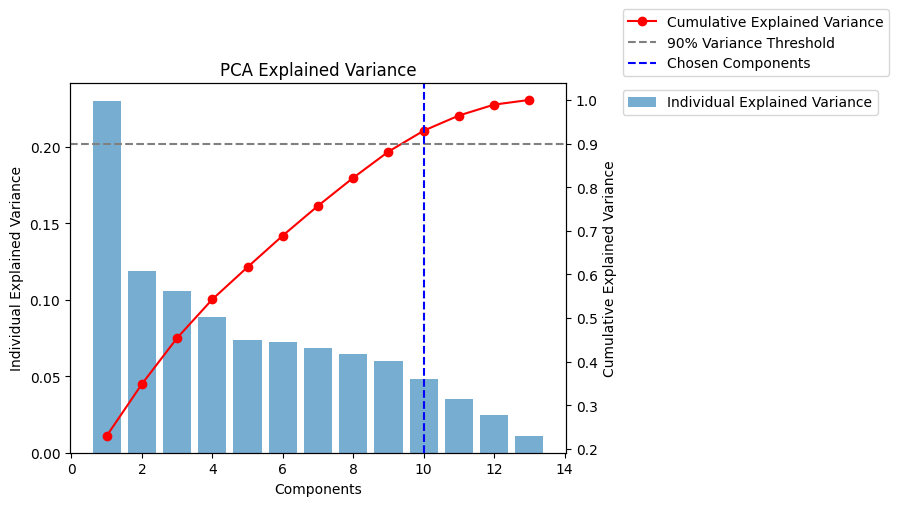

In [ ]:
import matplotlib.pyplot as plt

# quick visualization: plot PCA of X
pca_vis = PCA()
pca_vis.fit_transform(X_scaled)
np.cumsum(pca_vis.explained_variance_ratio_)

# display
fig, ax1 = plt.subplots()
ax1.bar(range(1, 14), pca_vis.explained_variance_ratio_, alpha=0.6, label='Individual Explained Variance')
ax1.set_xlabel('Components')
ax1.set_ylabel('Individual Explained Variance')
ax1.legend(bbox_to_anchor=(1.1, 1), loc='upper left')

ax2 = ax1.twinx()
ax2.plot(range(1, 14), np.cumsum(pca_vis.explained_variance_ratio_), marker='o', color='red', label='Cumulative Explained Variance')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.axhline(y=0.9, color='gray', linestyle='--', label='90% Variance Threshold')
ax2.axvline(x=10, color='blue', linestyle='--', label='Chosen Components')
ax2.legend(bbox_to_anchor=(1.1, 1), loc='lower left')

plt.title('PCA Explained Variance')
plt.show()

In [ ]:
np.cov(X_scaled.T)

array([[ 1.00000877e+00,  1.34326006e-01,  2.59078440e-01,
        -5.04486086e-02,  4.77351163e-01, -1.71532149e-01,
        -1.85609826e-01,  1.08626376e-01, -1.31620827e-01,
        -7.34354541e-02, -6.92248515e-02,  2.07220846e-01,
         1.22507531e-01],
       [ 1.34326006e-01,  1.00000877e+00,  7.61696526e-01,
         2.47854165e-01,  2.58939511e-01, -7.33914731e-01,
        -1.81882042e-01,  1.42509719e-01,  1.84796133e-01,
         5.85201374e-02, -7.83658469e-02,  1.87128253e-01,
         9.69553382e-02],
       [ 2.59078440e-01,  7.61696526e-01,  1.00000877e+00,
         2.12449222e-01,  2.79853741e-01, -5.89808917e-01,
        -4.33482261e-01,  6.08264123e-02,  7.68980073e-02,
        -3.47471729e-03, -4.17679171e-02,  1.91994106e-01,
         1.08588134e-01],
       [-5.04486086e-02,  2.47854165e-01,  2.12449222e-01,
         1.00000877e+00,  7.82694348e-02, -2.08232766e-01,
        -5.03286257e-02,  1.72744868e-02,  6.03241410e-04,
         2.43564343e-02,  5.71872057e

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(np.cov(X_scaled.T))

# sort by eigenvalue descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print(pca.explained_variance_ratio_)
print(eigenvalues / eigenvalues.sum())

[0.23006843 0.11890905 0.10556693 0.08857052 0.07380704 0.07228462
 0.06813764 0.06430927 0.0599742  0.04785919]
[0.23006843 0.11890905 0.10556693 0.08857052 0.07380704 0.07228462
 0.06813764 0.06430927 0.0599742  0.04785919 0.03479269 0.02497133
 0.01074909]


## Step 4: Perform K-Means

In [ ]:
from sklearn.cluster import KMeans

# determine optimal k using elbow method
inertias = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)

Text(0.5, 1.0, 'Elbow Method for Optimal k')

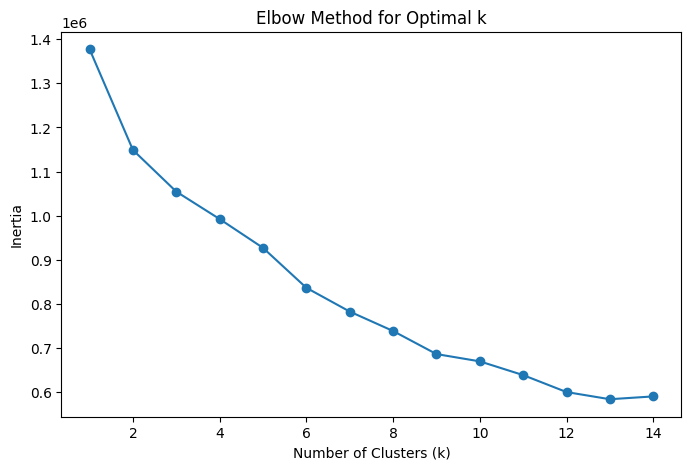

In [ ]:
# plot elbow curve

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

In [ ]:
# assign for k = 6
kmeans_final = KMeans(n_clusters=6, random_state=42)
df["cluster"] = kmeans_final.fit_predict(X_pca)

df['cluster'].value_counts().sort_index()

cluster
0    20097
1    18613
2    31352
3    23127
4    10848
5     9962
Name: count, dtype: int64

## Step 5: Interpret Clusters

In [ ]:
df.groupby("cluster")[feature_cols].mean()

,danceability,energy,loudness,tempo,valence,acousticness,instrumentalness,speechiness,liveness,duration_ms,mode,time_signature,explicit
cluster,,,,,,,,,,,,,
0,0.439795,0.815689,-5.529671,142.347450,0.396781,0.126416,0.049283,0.085952,0.362059,241551.497885,0.821217,3.913718,0.000249
1,0.424546,0.241010,-15.866768,108.291835,0.268417,0.817012,0.352238,0.050805,0.170643,211796.074786,0.717563,3.637028,0.002310
2,0.652026,0.654868,-7.131228,117.359390,0.629820,0.311889,0.021009,0.069783,0.166901,209831.473654,1.000000,3.974292,0.000000
3,0.637457,0.711338,-6.559295,120.344400,0.565847,0.221846,0.030177,0.082905,0.186664,221791.670385,0.000000,3.973927,0.000000
4,0.585416,0.743862,-8.673454,126.880393,0.326030,0.090878,0.777030,0.068422,0.173058,319245.624263,0.522032,3.949299,0.003595
5,0.636286,0.721369,-6.593992,121.388015,0.472159,0.226524,0.045896,0.213795,0.247489,203524.774844,0.582815,3.950713,0.969685


### Quick Analysis
This is a pretty readable result. We can analyze the means cluster-by-cluster:

0. "Hype/Live" - High energy, highest loudness, fastest tempo, not really accoustic or instrumental, high speechiness (comparison excludes cluster 5). Could be good for concerts.
1. "Chill/Acoustic" - Low energy, most quet, slowest tempo, highest acousticness, very instrumental (excluding cluster 4), lowest speechiness, not very lively.
2. "Feel-Good" - Highest danceability, high energy, 2nd loudest, high tempo, not very instrumental, but has a mode average of 1.0 (major key).
3. "Moody/Dance" - Similar to cluster 2 but has a darker or more emotional tone, as told by the mode average of 0.0 (minor key).
4. "Instrumental" - Focuses more on the instruments rather than vocality of the track (has the lowest speechiness). Probably classical, ambient, or electronic instrumental tracks.
5. "Rap/Explicit" - Almost entirely explicit => probably rap, also very speechy and energetic. 

### Sample Check
Let's sample a few random songs and see which cluster they fall in.
See if our ML analysis actually lines up with how we feel about these.

In [ ]:
for c in range(6):
    print(f"\n-----Cluster {c} random tracks:-----")
    print(df[df['cluster'] == c][['track_name', 'artists', 'track_genre']].sample(5))


-----Cluster 0 random tracks:-----
                                             track_name  \
40196              Tributo a Yehovah - Acústico Ao Vivo   
73386            In The Morning - Helsloot Remix - Edit   
100498                                        Si Te Vas   
41194   Jag Ger Dig Min Morgon (I Give You The Morning)   
46310                                    I Call You Out   

                                                  artists     track_genre  
40196   Adhemar De Campos;Pregador Luo;Fernandinho;Nel...          gospel  
73386                          Fritz Kalkbrenner;Helsloot  minimal-techno  
100498                                  Sonora Skandalera             ska  
41194                                     Håkan Hellström            goth  
46310                                     Joey Riot;Teddy           happy  

-----Cluster 1 random tracks:-----
                    track_name      artists track_genre
5430      rest well, my friend    Kainbeats       anime
64387

### Visualization

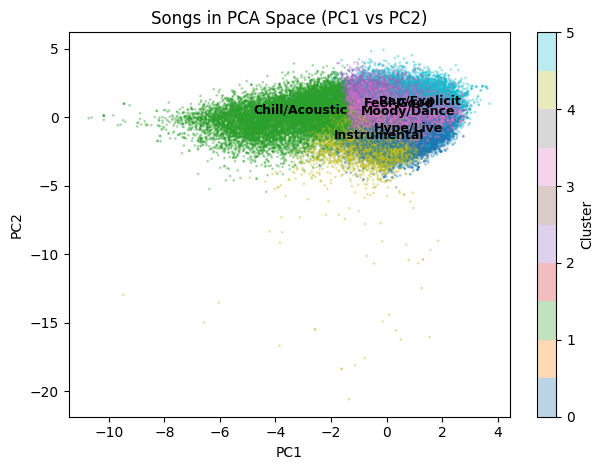

In [ ]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='tab10', alpha=0.3, s=1)

labels = ['Hype/Live', 'Chill/Acoustic', 'Feel-Good', 'Moody/Dance', 'Instrumental', 'Rap/Explicit']

for i, label in enumerate(labels):
    mask = df['cluster'] == i
    cx, cy = X_pca[mask, 0].mean(), X_pca[mask, 1].mean()
    plt.annotate(label, (cx, cy), fontsize=9, fontweight='bold', ha='center')

plt.colorbar(label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Songs in PCA Space (PC1 vs PC2)')
plt.tight_layout()

### Note: This doesn't really have anything to do with the data analysis. Just picking and choosing some tracks for personal interest.

In [ ]:
# Extra Fun: Index by track name and artist for easy lookup
df.set_index(['track_name', 'artists'], inplace=True)

In [ ]:
# example: lookup "Antidote" by Travis Scott
track_name = "Headbangeeeeerrrrr!!!!!"
artist_name = "BABYMETAL"

# Do Not Touch
cluster_names = [
    'Hype/Live',
    'Chill/Acoustic',
    'Feel-Good',
    'Moody/Dance',
    'Instrumental',
    'Rap/Explicit'
]

f'{track_name} by {artist_name} belongs to the {cluster_names[df.loc[(track_name, artist_name)]["cluster"].to_list()[0]]} cluster'

/var/folders/zl/lhwll31j7f780crsjcyyw64h0000gn/T/ipykernel_4002/3874520676.py:15: PerformanceWarning: indexing past lexsort depth may impact performance.
  f'{track_name} by {artist_name} belongs to the {cluster_names[df.loc[(track_name, artist_name)]["cluster"].to_list()[0]]} cluster'


'Headbangeeeeerrrrr!!!!! by BABYMETAL belongs to the Hype/Live cluster'

In [ ]:
# bonus: look at songs by artist "BABYMETAL"
artist_name = "BABYMETAL"
df[df.index.get_level_values('artists') == artist_name][['track_genre', 'cluster']]

,,track_genre,cluster
track_name,artists,,
Gimme Chocolate!!,BABYMETAL,j-idol,2
KARATE,BABYMETAL,j-idol,0
Headbangeeeeerrrrr!!!!!,BABYMETAL,j-idol,0
BxMxC,BABYMETAL,j-idol,0
Megitsune,BABYMETAL,j-idol,0
Shanti Shanti Shanti,BABYMETAL,j-idol,0
Divine Attack - Shingeki -,BABYMETAL,j-idol,0
Road of Resistance,BABYMETAL,j-idol,0
Distortion,BABYMETAL,j-idol,0
